In [23]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(knitr, tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, broom, stargazer, rdrobust)
source("../data-build/functions.R")
source("../data-build/rating_variables.R")

ma_final <- read_csv("../../hwk3/data/output/final-ma-data.csv")

Rows: 440877 Columns: 110
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (94): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Question 1

In [20]:
summary_table <- ma_final %>%
    filter(!is.na(Star_Rating)) %>%
  mutate(plan_market_share = avg_enrollment / avg_eligibles) %>%
  group_by(year) %>%
  summarize(
    `Mean Star Rating` = mean(Star_Rating, na.rm = TRUE),
    `Mean Enrollment` = mean(avg_enrollment, na.rm = TRUE),
    `Mean Market Share` = mean(plan_market_share, na.rm = TRUE),
    `Plan Count` = n()
  )

summary_table

year,Mean Star Rating,Mean Enrollment,Mean Market Share,Plan Count
<dbl>,<dbl>,<dbl>,<dbl>,<int>
2010,2.969968,345.9702,0.01245348,60519
2011,3.255317,388.3079,0.01506869,55249
2012,3.359556,410.6486,0.01656644,58169
2013,3.548875,406.7334,0.01631573,64174
2014,3.806049,451.1140,0.01785064,58636
2015,3.961542,482.5712,0.01930427,60819


# Question 2

In [22]:
# Filter for plans without a star rating
no_stars_plan_year <- ma_final %>%
  filter(is.na(Star_Rating)) %>%
  group_by(year, contractid, planid) %>%
  summarize(
    # Total enrollment for the plan across its service area
    total_plan_enrollment = sum(avg_enrollment, na.rm = TRUE),
    # Total MA enrollment in the counties served by this plan
    total_market_enrollment = sum(avg_enrolled, na.rm = TRUE),
    .groups = "drop"
  ) %>%
# Market Share for each plan
  mutate(plan_market_share = total_plan_enrollment / total_market_enrollment)

# Create table for unrated plans
summary_no_stars <- no_stars_plan_year %>%
  group_by(year) %>%
  summarize(
    `Mean Enrollment` = mean(total_plan_enrollment, na.rm = TRUE),
    `Mean Market Share` = mean(plan_market_share, na.rm = TRUE),
    `Count of Plans` = n()
  )

summary_no_stars

year,Mean Enrollment,Mean Market Share,Count of Plans
<dbl>,<dbl>,<dbl>,<int>
2010,1289.6567,0.009691769,964
2011,1276.4435,0.016652349,649
2012,1189.5571,0.012039689,494
2013,764.2311,0.014137061,409
2014,970.8587,0.015523844,489
2015,1121.8427,0.010754724,533


# Question 3

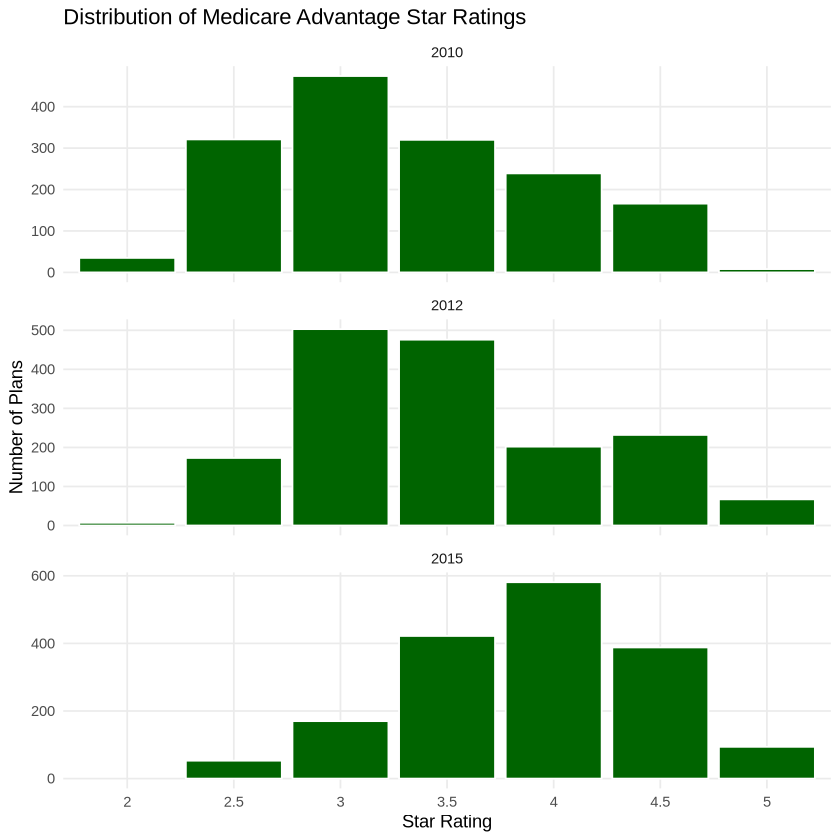

In [34]:
star_dist_data <- ma_final %>%
  filter(year %in% c(2010, 2012, 2015)) %>%
  distinct(year, contractid, planid, Star_Rating) %>%
  filter(!is.na(Star_Rating))

ggplot(star_dist_data, aes(x = factor(Star_Rating))) +
  geom_bar(fill = "darkgreen", color = "white") +
  facet_wrap(~year, ncol = 1, scales = "free_y") +
  theme_minimal() +
  labs(
    title = "Distribution of Medicare Advantage Star Ratings",
    x = "Star Rating",
    y = "Number of Plans"
  ) +
    theme(panel.grid.minor = element_blank())

The distribution has shifted rightward over time, showing a general increase in plan ratings. In 2010, the majority of MA ratings were concentrated at 3. This held true in 2012 with an additional increase in 3.5 ratings. By 2015, we see that the highest number of plans are 4 stars (~600), with 3.5 and 4.5 stars close behind at ~400 plans each.

# Question 4

In [5]:
reg_data <- ma_final %>%
  group_by(year, contractid, planid) %>%
  summarize(
    star_rating = mean(Star_Rating, na.rm = TRUE),
    plan_enrollment = sum(avg_enrollment, na.rm = TRUE),
    total_market_enrollment = sum(avg_enrolled, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(market_share = plan_enrollment / total_market_enrollment) %>%
  filter(!is.na(star_rating), !is.na(market_share)) %>%
  # Create star rating factor (Excluded Group = 2.5 or below)
  mutate(star_cat = case_when(
    star_rating <= 2.5 ~ "stars_2.5_or_below",
    star_rating == 3.0 ~ "stars_3.0",
    star_rating == 3.5 ~ "stars_3.5",
    star_rating == 4.0 ~ "stars_4.0",
    star_rating >= 4.5 ~ "stars_4.5_plus"
  )) %>%
  mutate(star_cat = factor(star_cat, levels = c("stars_2.5_or_below", "stars_3.0", "stars_3.5", "stars_4.0", "stars_4.5_plus")))

# Run regression for each year
models_list <- map(2010:2015, ~ lm(market_share ~ star_cat, data = filter(reg_data, year == .x)))

# Table of results using stargazer
stargazer(models_list, 
          type = "text",
          column.labels = as.character(2010:2015),
          dep.var.labels = "Market Share",
          covariate.labels = c("3 Stars", "3.5 Stars", "4 Stars", "4.5+ Stars"),
          omit.stat = c("f", "ser"),
          title = "OLS Regression of Market Share on Star Ratings (2010-2015)",
          align = TRUE)


OLS Regression of Market Share on Star Ratings (2010-2015)
                             Dependent variable:                 
             ----------------------------------------------------
                                 Market Share                    
               2010     2011     2012     2013    2014     2015  
               (1)      (2)      (3)      (4)      (5)     (6)   
-----------------------------------------------------------------
3 Stars       0.007*   0.010*   0.0001  0.016***  0.006   -0.005 
             (0.004)  (0.005)  (0.005)  (0.005)  (0.011) (0.007) 
                                                                 
3.5 Stars    0.013***  0.009    -0.003  0.011**   0.006   0.002  
             (0.004)  (0.005)  (0.005)  (0.005)  (0.011) (0.007) 
                                                                 
4 Stars      0.014***  0.006    -0.008   0.005    0.003   -0.006 
             (0.004)  (0.006)  (0.005)  (0.005)  (0.011) (0.007) 
                

# Question 5

In [18]:
# Filter for 2010
ma_2010 <- ma_final %>%
  filter(year == 2010) %>%
  select(contractid, planid, Star_Rating, avg_enrollment, plan_type, partd, any_of(rating.vars.2015))

# Calculate running variable (raw score) using rowmeans
rd_table_data <- ma_2010 %>%
  mutate(
    raw_score = rowMeans(
      select(., any_of(rating.vars.2015)) %>% select(where(is.numeric)), 
      na.rm = TRUE
    )
  ) %>%
  filter(!is.na(raw_score)) %>%
  mutate(
    raw_decimal = raw_score - floor(raw_score),
    # CMS Rounding Rules
    rounded_up = case_when(
      raw_decimal >= 0.25 & raw_decimal < 0.50 & Star_Rating > floor(raw_score) ~ TRUE,
      raw_decimal >= 0.75 & Star_Rating > (floor(raw_score) + 0.5) ~ TRUE,
      TRUE ~ FALSE
    )
  )

# Create summary table
rounding_summary <- rd_table_data %>%
  filter(rounded_up == TRUE) %>%
  group_by(Star_Rating) %>%
  summarize(`Number of Plans Rounded Up` = n()) %>%
  rename(`Star Rating` = Star_Rating) %>%
  arrange(`Star Rating`)

rounding_summary

Star Rating,Number of Plans Rounded Up
<dbl>,<int>
2.0,243
2.5,10601
3.0,3970
3.5,4122
4.0,2376
4.5,1310
5.0,97


# Question 6

In [19]:
# Calculate raw scores
rd_table_data <- ma_2010 %>%
  mutate(
    raw_score = rowMeans(
      select(., any_of(rating.vars.2015)) %>% select(where(is.numeric)), 
      na.rm = TRUE
    )
  ) %>%
  filter(!is.na(raw_score))

# Aggregate to plan-year level
rd_enrollment_data <- rd_table_data %>%
  group_by(contractid, planid) %>%
  summarize(
    raw_score = mean(raw_score, na.rm = TRUE),
    total_enrollment = sum(avg_enrollment, na.rm = TRUE),
    .groups = "drop"
  )

# RD estimation function (bandwidth = 0.125)
estimate_rd <- function(data, threshold, bw = 0.125) {
  data %>%
    mutate(dist = raw_score - threshold) %>%
    filter(abs(dist) <= bw) %>%
    mutate(treated = ifelse(dist >= 0, 1, 0)) %>%
    lm(total_enrollment ~ treated + dist, data = .)
}

# Run regressions for the specific thresholds (2.75 is the cutoff for 3.0 stars, 3.25 is the cutoff for 3.5 stars)
model_30 <- estimate_rd(rd_enrollment_data, 2.75)
model_35 <- estimate_rd(rd_enrollment_data, 3.25)

# Summary table using stargazer
stargazer(model_30, model_35,
          type = "text",
          column.labels = c("3.0 vs 2.5", "3.5 vs 3.0"),
          dep.var.labels = "Total Enrollments",
          covariate.labels = c("Treatment (Higher Star Rating)", "Running Variable (Distance)"),
          title = "RD Estimates using MA 2010 Data",
          omit.stat = c("f", "ser"))


RD Estimates using MA 2010 Data
                                   Dependent variable:     
                               ----------------------------
                                    Total Enrollments      
                                 3.0 vs 2.5    3.5 vs 3.0  
                                    (1)            (2)     
-----------------------------------------------------------
Treatment (Higher Star Rating) -5,792.156***    1,321.590  
                                (2,114.001)    (1,649.416) 
                                                           
Running Variable (Distance)     29,235.720**   -6,487.592  
                                (14,756.730)  (11,185.220) 
                                                           
Constant                        7,661.156***  3,060.992*** 
                                (1,535.065)    (1,000.816) 
                                                           
-----------------------------------------------------------
Observa

# Question 7

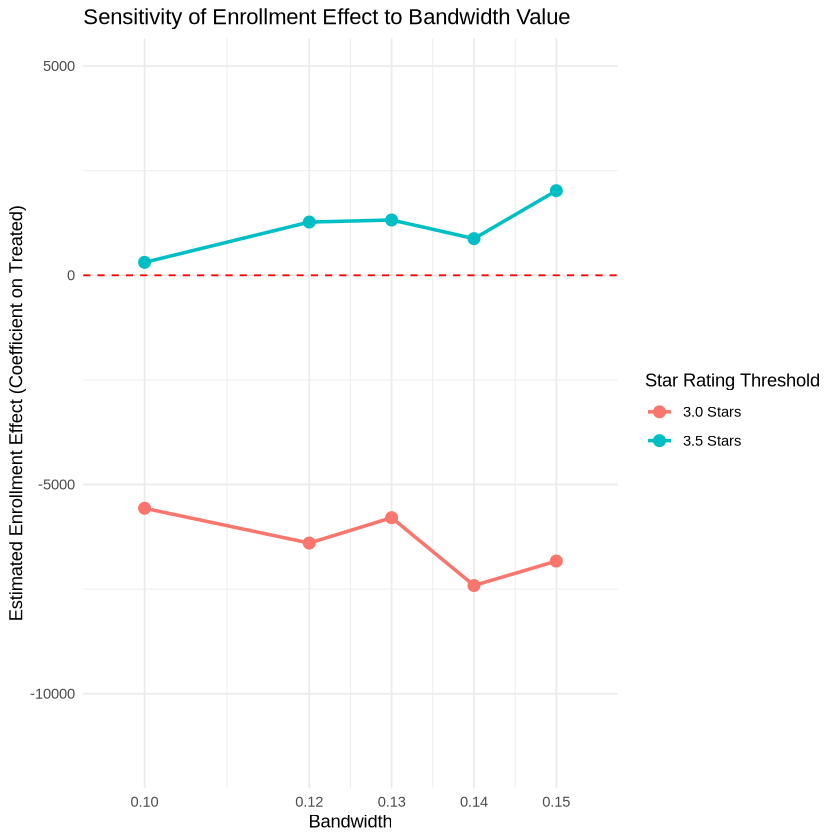

In [35]:
# Define parameters and bandwidths for analysis
thresholds <- c("3.0 Stars" = 2.75, "3.5 Stars" = 3.25)
bandwidths <- c(0.1, 0.12, 0.13, 0.14, 0.15)

# Create a function to run model and extract estimate
run_sensitivity <- function(thresh_val, thresh_label, bw) {
  model_data <- rd_enrollment_data %>%
    mutate(dist = raw_score - thresh_val) %>%
    filter(abs(dist) <= bw) %>%
    mutate(treated = ifelse(dist >= 0, 1, 0))
  
  fit <- lm(total_enrollment ~ treated + dist, data = model_data)
  
  # Data frame with estimate and standard error
  broom::tidy(fit, conf.int = TRUE) %>%
    filter(term == "treated") %>%
    mutate(bandwidth = bw, threshold = thresh_label)
}

# Run the model across all combos
sensitivity_results <- map2_dfr(
  rep(thresholds, each = length(bandwidths)),
  rep(names(thresholds), each = length(bandwidths)),
  ~run_sensitivity(.x, .y, bandwidths[match(.y, names(thresholds)) + (match(.x, thresholds) - 1) * 0])
)

# Correction for the map: cleaner version
sensitivity_results <- expand.grid(thresh_name = names(thresholds), bw = bandwidths) %>%
  rowwise() %>%
  do(run_sensitivity(thresholds[[.$thresh_name]], .$thresh_name, .$bw))


# Create graph
ggplot(sensitivity_results, aes(x = bandwidth, y = estimate, color = threshold)) +
    geom_line(size = 1) +
    geom_point(size = 3) +
    geom_errorbar(aes(ymin = conf.low, ymax = conf.high), linewidth = 0.005) +
    scale_x_continuous(breaks = bandwidths) +
  theme_minimal() +
  labs(
    title = "Sensitivity of Enrollment Effect to Bandwidth Value",
    x = "Bandwidth",
    y = "Estimated Enrollment Effect (Coefficient on Treated)",
    color = "Star Rating Threshold"
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red")

As we move from left to right (bandwidth of 0.1 to 0.15), we are including more plans that are further away from the thresholds. At the same time, we are looking at the effect of a 3-star versus a 2.5 star rating (red line) on enrollments and a 3.5 vs 3-star rating (blue line). What do the fluctuations in each of the lines show?

# Question 8

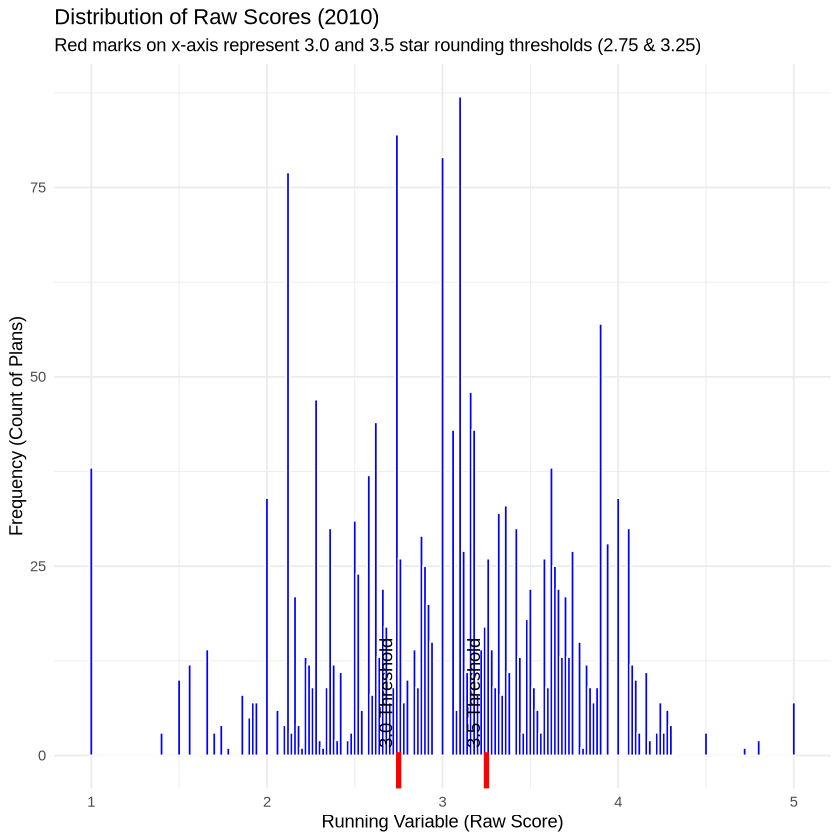

In [33]:
ggplot(rd_enrollment_data, aes(x = raw_score)) +
geom_histogram(binwidth = 0.02, fill = "blue", color = "white") +
  
# Mark thresholds
  geom_rug(data = data.frame(raw_score = c(2.75, 3.25)), 
           sides = "b", 
           color = "red", 
           linewidth = 1.5, 
           length = unit(0.05, "npc")) + # Adjust length to make the "mark" taller or shorter
  
  theme_minimal() +
  labs(
    title = "Distribution of Raw Scores (2010)",
    subtitle = "Red marks on x-axis represent 3.0 and 3.5 star rounding thresholds (2.75 & 3.25)",
    x = "Running Variable (Raw Score)",
    y = "Frequency (Count of Plans)"
  ) +
  annotate("text", x = 2.75, y = 1, label = "3.0 Threshold", color = "black", angle = 90, vjust = -0.5, hjust = 0) +
  annotate("text", x = 3.25, y = 1, label = "3.5 Threshold", color = "black", angle = 90, vjust = -0.5, hjust = 0)

The running variable (raw score) before and after the thresholds (red lines) is not notably bunched, showing that there doesn't seem to be much of a difference.

# Question 9

In [23]:
balance_data <- ma_2010 %>%
  mutate(
    raw_score = rowMeans(select(., any_of(rating.vars.2015)) %>% select(where(is.numeric)), na.rm = TRUE),
    is_hmo = ifelse(grepl("HMO", plan_type, ignore.case = TRUE), 1, 0),
    has_partd = ifelse(partd == "Yes", 1, 0)
  ) %>%
  filter(!is.na(raw_score))

# RD Balance Test at 3.0 stars (threshold 2.75)
hmo_3 <- rdrobust(y = balance_data$is_hmo, x = balance_data$raw_score, c = 2.75, h = 0.125)
partd_3 <- rdrobust(y = balance_data$has_partd, x = balance_data$raw_score, c = 2.75, h = 0.125)

# RD Balance Test at 3.5 stars (threshold 3.25)
hmo_35 <- rdrobust(y = balance_data$is_hmo, x = balance_data$raw_score, c = 3.25, h = 0.125)
partd_35 <- rdrobust(y = balance_data$has_partd, x = balance_data$raw_score, c = 3.25, h = 0.125)

# View results
summary(hmo_3)
summary(partd_3)

Sharp RD estimates using local polynomial regression.

Number of Obs.                95203
BW type                      Manual
Kernel                   Triangular
VCE method                       NN

Number of Obs.                55252        39951
Eff. Number of Obs.           12918         5017
Order est. (p)                    1            1
Order bias  (q)                   2            2
BW est. (h)                   0.125        0.125
BW bias (b)                   0.125        0.125
rho (h/b)                     1.000        1.000
Unique Obs.                   55252        39951

        Method     Coef. Std. Err.         z     P>|z|      [ 95% C.I. ]       
  Conventional    -0.563     0.007   -84.146     0.000    [-0.576 , -0.550]    
        Robust         -         -  -119.253     0.000    [-1.007 , -0.974]    
Sharp RD estimates using local polynomial regression.

Number of Obs.                95203
BW type                      Manual
Kernel                   Triangular
VCE 

In [28]:
# Summary table of p-values for 3.0 and 3.5 thresholds
results_table <- data.frame(
  Characteristic = c("HMO Status", "Part D Status"),
  `P-Value at 3.0 Stars (2.75)` = c(hmo_30$pv[1], partd_30$pv[1]),
  `P-Value at 3.5 Stars (3.25)` = c(hmo_35$pv[1], partd_35$pv[1]),
  check.names = FALSE
)

results_table

Characteristic,P-Value at 3.0 Stars (2.75),P-Value at 3.5 Stars (3.25)
<chr>,<dbl>,<dbl>
HMO Status,0.000000e+00,1.255537e-19
Part D Status,2.236214e-96,1.728727e-06


# Question 10

Looking at the results of questions 5-9, we do not see an effect of star rating on MA enrollments.